## Install

Installation is easy just grab it form pip

In [5]:
# !pip install virtughan==0.7.0

## Setup

Define the parameters for your computation

Use this for visual image timeseries
```python
formula="band1"
band1="visual"
band2=None
operation=None
timeseries=True
```

In [6]:
# Define the bounding box
bbox =  [-17.942562103271488,28.569682805210718,-17.839050292968754,28.64689695054486] # cumbre vieja volcano spain area

# Define the parameters
start_date = "2021-10-01"
end_date = "2021-12-30"
cloud_cover = 10
formula = "(band1-band2)/(band1+band2)"  # NBR
band1 = "nir08"
band2 = "swir22"
operation = "max"
output_dir = "virtughan_output"
timeseries = True
workers = 1 # no of parallel workers
smart_filter=False

## Cleanup
Lets clear if there are previous output in the dir

In [7]:
import shutil , os
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)

## Example compute on time dimension
You can run computation now , You can visualize the results or download them from the files directly after computation is done

In [8]:
from virtughan.engine import VirtughanProcessor

processor = VirtughanProcessor(
    bbox,
    start_date,
    end_date,
    cloud_cover,
    formula,
    band1,
    band2,
    operation,
    timeseries,
    output_dir,
    workers=workers,
    smart_filter=smart_filter,
    cmap="RdYlGn"
)
processor.compute()

Engine starting...

Searching STAC catalog...

Total scenes found: 11

Scenes covering input area: 11

Scenes after removing overlaps: 6

Output()

Aggregating results...

Saving aggregated result with colormap...

Creating GIF and zipping TIFF files...

Saved intermediate images ZIP to virtughan_output/tiff_files.zip


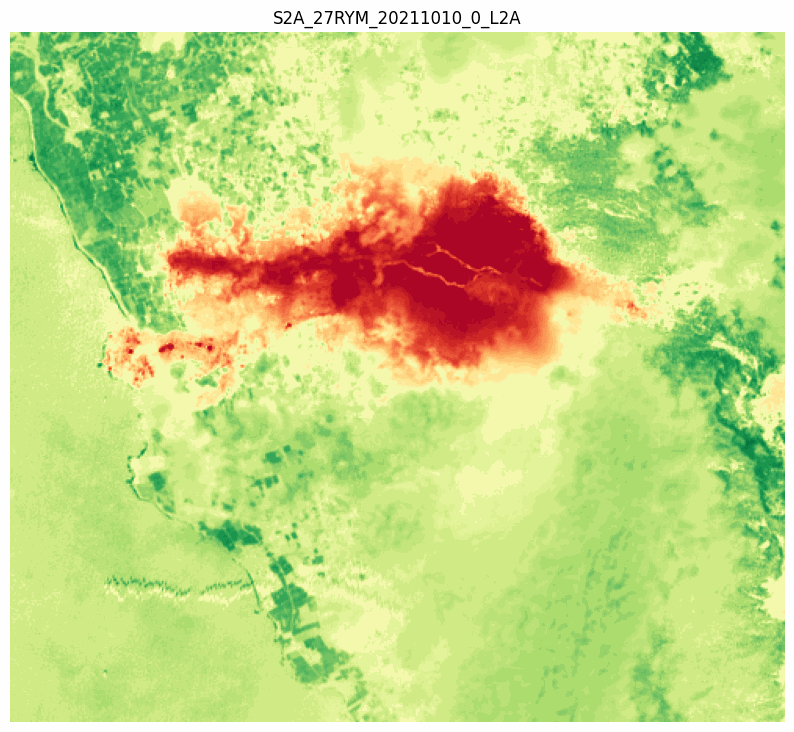

In [9]:
from IPython.display import Image
Image(open(os.path.join(output_dir,'output.gif'),'rb').read())

## Example on the fly tile computation

Here computation will be done alike google earth engine , you zoom out do computation , zoom in do computation based on your formula and resolution will differ accordingly as resampling will happen

In [10]:
import mercantile
from PIL import Image
from io import BytesIO
from virtughan.tile import TileProcessor

# Define the parameters
lat, lon = 28.28139, 83.91866
zoom_level = 12
x, y, z = mercantile.tile(lon, lat, zoom_level)

tile_processor = TileProcessor()

image_bytes, feature = await tile_processor.cached_generate_tile(
    x=x,
    y=y,
    z=z,
    start_date="2020-01-01",
    end_date="2025-01-01",
    cloud_cover=30,
    band1="red",
    band2="nir",
    formula="(band2-band1)/(band2+band1)",
    colormap_str="RdYlGn",
)

image = Image.open(BytesIO(image_bytes))

print(f"Tile: {x}_{y}_{z}")
print(f"Date: {feature['properties']['datetime']}")
print(f"Cloud Cover: {feature['properties']['eo:cloud_cover']}%")

image.save(f'tile_{x}_{y}_{z}.png')


Tile: 3002_1712_12
Date: 2024-12-30T05:10:56.883000Z
Cloud Cover: 1.140427%


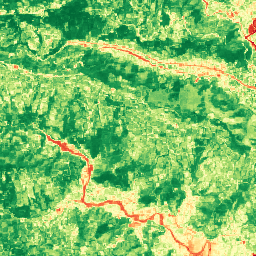

In [11]:
from IPython.display import Image as display_image
display_image(f'tile_{x}_{y}_{z}.png')


## Extract Sentinel-2 Images for your AOI
This example showcase how you can select the band you want and extract sentinel-2 images just for your area of interest

In [12]:
import os

bbox = [83.84765625, 28.22697003891833, 83.935546875, 28.304380682962773]
start_date = "2024-12-15"
end_date = "2024-12-31"
cloud_cover = 30
bands_list = ["blue","green","red", "nir","swir16","swir22"] # order of the bands will result order in the resulting output
output_dir = "./sentinel_images"
workers = 1

os.makedirs(output_dir, exist_ok=True)

In [13]:
from virtughan.extract import ExtractProcessor
from virtughan.collections import get_collection

config = get_collection("sentinel-2-l2a")
print("Available Sentinel-2 bands:", config.band_names)

extractor = ExtractProcessor(
    bbox,
    start_date,
    end_date,
    cloud_cover,
    bands_list,
    output_dir,
    workers=workers,
)
extractor.extract()

Available Sentinel-2 bands: ['red', 'green', 'blue', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'aot', 'coastal', 'nir09', 'scl', 'visual']


Extracting bands...

Total scenes found: 4

Scenes covering input area: 4

Scenes after removing overlaps: 4

...

Output()

Stacking bands for S2B_44RQS_20241215_0_L2A

Stacking bands for S2A_44RQS_20241220_0_L2A

Stacking bands for S2B_44RQS_20241225_0_L2A

Stacking bands for S2A_44RQS_20241230_0_L2A

## Extract Landsat C2 L2 Images for your AOI
Same workflow as Sentinel-2 but using Landsat collection from Planetary Computer

In [14]:
from virtughan.collections import get_collection

landsat_config = get_collection("landsat-c2-l2")
print("Available Landsat bands:", landsat_config.band_names)

landsat_bbox = [83.84765625, 28.22697003891833, 83.935546875, 28.304380682962773]
landsat_start_date = "2024-06-01"
landsat_end_date = "2024-08-31"
landsat_cloud_cover = 30
landsat_bands_list = ["blue", "green", "red", "nir08", "swir16", "swir22"]
landsat_output_dir = "./landsat_images"
os.makedirs(landsat_output_dir, exist_ok=True)

Available Landsat bands: ['red', 'green', 'blue', 'nir08', 'swir16', 'swir22', 'coastal', 'lwir11']


In [15]:
from virtughan.extract import ExtractProcessor

landsat_extractor = ExtractProcessor(
    landsat_bbox,
    landsat_start_date,
    landsat_end_date,
    landsat_cloud_cover,
    landsat_bands_list,
    landsat_output_dir,
    workers=1,
    collection="landsat-c2-l2",
)
landsat_extractor.extract()

Extracting bands...

Total scenes found: 5

Scenes covering input area: 1

Scenes after removing overlaps: 1

Filter from : 2024-06-08 to : 2024-06-08
Selecting 1 image per 15 days


Scenes after smart filter: 1

Output()

Stacking bands for LC09_L2SP_142040_20240608_02_T1

## Landsat NDVI Computation
Compute NDVI using Landsat C2 L2 bands. Note that Landsat uses `nir08` instead of Sentinel-2's `nir`

In [16]:
landsat_ndvi_output = "./landsat_ndvi_output"
if os.path.exists(landsat_ndvi_output):
    shutil.rmtree(landsat_ndvi_output)

from virtughan.engine import VirtughanProcessor

landsat_processor = VirtughanProcessor(
    bbox=landsat_bbox,
    start_date="2024-06-01",
    end_date="2024-08-31",
    cloud_cover=30,
    formula="(band2 - band1) / (band2 + band1)",
    band1="red",
    band2="nir08",
    operation="median",
    timeseries=True,
    output_dir=landsat_ndvi_output,
    workers=1,
    collection="landsat-c2-l2",
    cmap="RdYlGn",
)
landsat_processor.compute()

Engine starting...

Searching STAC catalog...

Total scenes found: 5

Scenes covering input area: 1

Scenes after removing overlaps: 1

...

Output()

Aggregating results...

Saving aggregated result with colormap...

Creating GIF and zipping TIFF files...

Saved intermediate images ZIP to ./landsat_ndvi_output/tiff_files.zip


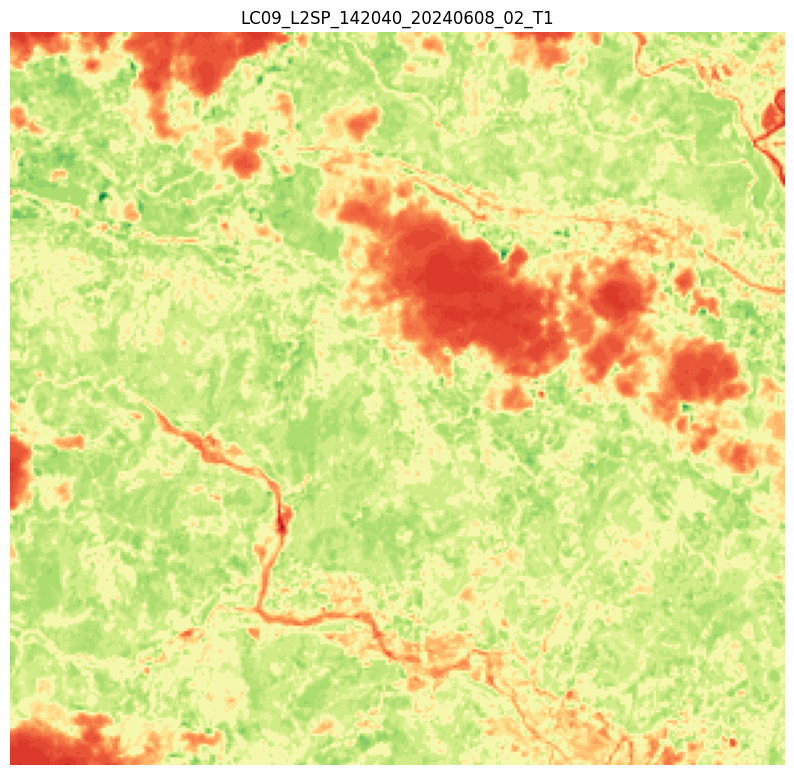

In [17]:
from IPython.display import Image
Image(open(os.path.join(landsat_ndvi_output, "output.gif"), "rb").read())